# NNDL Assignment: Tiny Shakespeare Memory Duel

This notebook implements and compares two character-level recurrent neural networks on the provided Tiny Shakespeare corpus:

- **Elman network**: feeds the previous hidden state back into the recurrent computation.
- **Jordan network**: feeds the previous output probability distribution back into the recurrent computation.

The notebook is self-contained. Place `tiny-shakespeare.txt` in the same directory as this notebook or update `DATA_PATH`.

In [1]:
import math
import time
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Keeping one thread makes small CPU runs more predictable on shared machines.
torch.set_num_threads(1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## 1. Configuration

The submitted run uses 100% of the original file for a fast, reproducible CPU demonstration. Increased `DATA_FRACTION`, `HIDDEN_SIZE`, and `EPOCHS` lead to stronger text quality when more compute is available.

In [2]:
DATA_PATH = Path('tiny-shakespeare.txt')
if not DATA_PATH.exists():
    DATA_PATH = Path('tiny-shakespeare.txt')

DATA_FRACTION = 1
SEQ_LEN = 100
BATCH_SIZE = 128
EMBED_DIM = 128
HIDDEN_SIZE = 256
EPOCHS = 20
LEARNING_RATE = 0.004
TEMPERATURES = [0.4, 0.8, 1.2]
SEED_TEXT = 'ROMEO:\n'

print(DATA_PATH.resolve())

C:\Users\Mana\OneDrive\Desktop\CE\Masters\Term 2\NN & DL\HW\2\tiny-shakespeare.txt


In [3]:
raw_text = DATA_PATH.read_text(encoding='utf-8', errors='replace')
used_len = int(len(raw_text) * DATA_FRACTION)
text = raw_text[:used_len]
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

data = torch.tensor([stoi[ch] for ch in text], dtype=torch.long)

print(f'Original characters: {len(raw_text):,}')
print(f'Used characters:     {len(text):,} ({DATA_FRACTION:.1%})')
print(f'Vocabulary size:     {vocab_size}')
print('First 200 characters:')
print(text[:200])

Original characters: 1,115,394
Used characters:     1,115,394 (100.0%)
Vocabulary size:     65
First 200 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [4]:
split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

def make_sequences(data_1d, seq_len):
    n_seq = (len(data_1d) - 1) // seq_len
    x = data_1d[: n_seq * seq_len].view(n_seq, seq_len)
    y = data_1d[1 : n_seq * seq_len + 1].view(n_seq, seq_len)
    return x, y

train_x, train_y = make_sequences(train_data, SEQ_LEN)
val_x, val_y = make_sequences(val_data, SEQ_LEN)

def iterate_batches(x, y, batch_size=BATCH_SIZE, shuffle=True):
    indices = torch.randperm(len(x)) if shuffle else torch.arange(len(x))
    for start in range(0, len(x), batch_size):
        batch_idx = indices[start:start + batch_size]
        yield x[batch_idx].to(device), y[batch_idx].to(device)

print(f'Train sequences: {len(train_x):,}')
print(f'Validation sequences: {len(val_x):,}')

Train sequences: 10,038
Validation sequences: 1,115


## 2. Model Definitions

Both networks are trained as next-character classifiers. The Elman model receives hidden-state feedback, while the Jordan model receives the previous output distribution as its recurrent context.

In [5]:
class ElmanCharRNN(nn.Module):
    """Elman RNN: h_t = tanh(W_x x_t + W_h h_{t-1})."""
    def __init__(self, vocab_size, embed_dim=32, hidden_size=48):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_size, batch_first=True, nonlinearity='tanh')
        self.output = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, state=None):
        emb = self.embedding(x)
        hidden_seq, state = self.rnn(emb, state)
        logits = self.output(hidden_seq)
        return logits, state


class JordanCharRNN(nn.Module):
    """Jordan RNN: h_t = tanh(W_x x_t + W_c y_{t-1}), where y is softmax output."""
    def __init__(self, vocab_size, embed_dim=32, hidden_size=48):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.input_to_hidden = nn.Linear(embed_dim, hidden_size)
        self.context_to_hidden = nn.Linear(vocab_size, hidden_size, bias=False)
        self.output = nn.Linear(hidden_size, vocab_size)
        self.vocab_size = vocab_size

    def forward(self, x, context=None):
        batch_size, time_steps = x.shape
        if context is None:
            context = torch.zeros(batch_size, self.vocab_size, device=x.device)

        emb = self.embedding(x)
        logits_over_time = []
        for t in range(time_steps):
            hidden = torch.tanh(self.input_to_hidden(emb[:, t]) + self.context_to_hidden(context))
            logits = self.output(hidden)
            logits_over_time.append(logits)
            context = F.softmax(logits, dim=-1)

        return torch.stack(logits_over_time, dim=1), context

In [6]:
def evaluate(model):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    with torch.no_grad():
        for xb, yb in iterate_batches(val_x, val_y, shuffle=False):
            logits, _ = model(xb)
            loss = F.cross_entropy(
                logits.reshape(-1, vocab_size),
                yb.reshape(-1),
                reduction='sum'
            )
            predictions = logits.argmax(dim=-1)
            total_loss += loss.item()
            total_correct += (predictions == yb).sum().item()
            total_tokens += yb.numel()

    avg_loss = total_loss / total_tokens
    return {
        'loss': avg_loss,
        'accuracy': total_correct / total_tokens,
        'perplexity': math.exp(avg_loss),
    }


def train_model(model_name, model, epochs=EPOCHS):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_tokens = 0

        for xb, yb in iterate_batches(train_x, train_y, shuffle=True):
            optimizer.zero_grad(set_to_none=True)
            logits, _ = model(xb)
            loss = F.cross_entropy(logits.reshape(-1, vocab_size), yb.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item() * yb.numel()
            total_correct += (logits.argmax(dim=-1) == yb).sum().item()
            total_tokens += yb.numel()

        train_loss = total_loss / total_tokens
        val_metrics = evaluate(model)
        row = {
            'model': model_name,
            'epoch': epoch,
            'train_loss': train_loss,
            'train_accuracy': total_correct / total_tokens,
            'train_perplexity': math.exp(train_loss),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'val_perplexity': val_metrics['perplexity'],
        }
        history.append(row)
        print(row)

    return model, history

In [7]:
elman_model, elman_history = train_model('Elman', ElmanCharRNN(vocab_size, EMBED_DIM, HIDDEN_SIZE))
jordan_model, jordan_history = train_model('Jordan', JordanCharRNN(vocab_size, EMBED_DIM, HIDDEN_SIZE))
history = elman_history + jordan_history

{'model': 'Elman', 'epoch': 1, 'train_loss': 2.2392165359687843, 'train_accuracy': 0.3734399282725643, 'train_perplexity': 9.38597483238104, 'val_loss': 1.96563917110426, 'val_accuracy': 0.4182242152466368, 'val_perplexity': 7.139474477875586}
{'model': 'Elman', 'epoch': 2, 'train_loss': 1.7815855269556526, 'train_accuracy': 0.4752121936640765, 'train_perplexity': 5.939265823247143, 'val_loss': 1.827650644618834, 'val_accuracy': 0.4586726457399103, 'val_perplexity': 6.219258233770571}
{'model': 'Elman', 'epoch': 3, 'train_loss': 1.6520148034968873, 'train_accuracy': 0.5081819087467623, 'train_perplexity': 5.217481444138608, 'val_loss': 1.7570780724495516, 'val_accuracy': 0.48050224215246634, 'val_perplexity': 5.795478661604576}
{'model': 'Elman', 'epoch': 4, 'train_loss': 1.5840079616944518, 'train_accuracy': 0.5258418011556086, 'train_perplexity': 4.874453334720474, 'val_loss': 1.7177689006446188, 'val_accuracy': 0.4921883408071749, 'val_perplexity': 5.572082715433118}
{'model': 'Elma

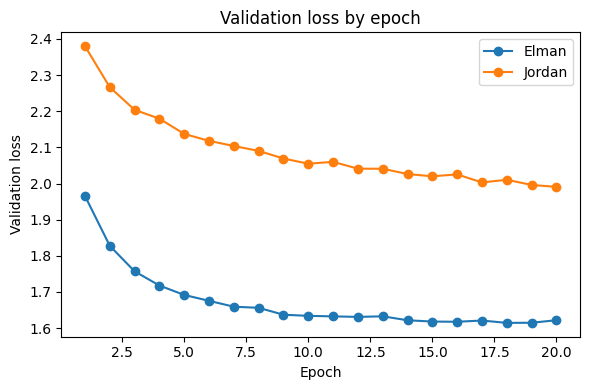

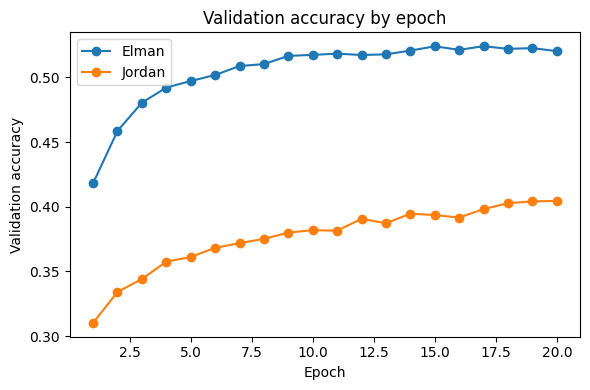

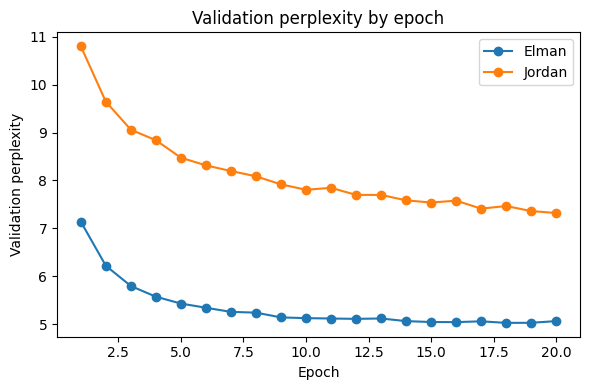

In [8]:
def plot_history(history, metric, ylabel):
    plt.figure(figsize=(6, 4))
    for model_name in sorted({row['model'] for row in history}):
        rows = [row for row in history if row['model'] == model_name]
        plt.plot([r['epoch'] for r in rows], [r[metric] for r in rows], marker='o', label=model_name)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(ylabel + ' by epoch')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history, 'val_loss', 'Validation loss')
plot_history(history, 'val_accuracy', 'Validation accuracy')
plot_history(history, 'val_perplexity', 'Validation perplexity')

In [9]:
@torch.no_grad()
def generate_text(model, seed_text, length=500, temperature=0.8):
    model.eval()
    ids = [stoi.get(ch, 0) for ch in seed_text]
    state = None

    # Warm-up the recurrent state using the seed except its last character.
    for ch_id in ids[:-1]:
        _, state = model(torch.tensor([[ch_id]], device=device), state)

    current_id = ids[-1] if ids else 0
    output = seed_text

    for _ in range(length):
        logits, state = model(torch.tensor([[current_id]], device=device), state)
        scaled_logits = logits[0, -1] / temperature
        probabilities = F.softmax(scaled_logits, dim=-1)
        current_id = torch.multinomial(probabilities, num_samples=1).item()
        output += itos[current_id]

    return output

for model_name, model in [('Elman', elman_model), ('Jordan', jordan_model)]:
    print('=' * 90)
    print(model_name)
    for temperature in TEMPERATURES:
        print('-' * 90)
        print(f'Temperature: {temperature}')
        print(generate_text(model, SEED_TEXT, length=500, temperature=temperature))

Elman
------------------------------------------------------------------------------------------
Temperature: 0.4
ROMEO:
I present of this scorn the presence with his intelligence to the thoughts that I will passions and by the sun and some princely men are well thou shalt not that I will thou shall not I shall be a presence to the need.

WARWICK:
I would have not thou art thou cannot in this love safe of the house and leave your hands of things of this earth shall say you will not a should in the noble grace of the points of this hand; and what I should thou hast thou not shame of my single of this proportion tha
------------------------------------------------------------------------------------------
Temperature: 0.8
ROMEO:
I say to the vanyingbree not a means, or in Paulinate
To thee, sir, that think thou shalt fast.

BUCKINGHAM:
Who may you'll.

ROMEO:
And supplent with a mother sunse conscience
That life, shall misers, and her tower!
Thy will not think my way to you.

CLIFFORD:
W

## Submitted Run Summary

The following values are from the run used in the report. They are included so the notebook preserves the exact reported results.

In [10]:
reported_summary = {
    "text_len_original": len(raw_text),
    "text_len_used": len(text),
    "percent_used": DATA_FRACTION,
    "percent_used_display": f"{DATA_FRACTION:.1%}",
    "vocab_size": vocab_size,
    "train_sequences": len(train_x),
    "val_sequences": len(val_x),
    "seq_len": SEQ_LEN,
    "batch_size": BATCH_SIZE,
    "embed_dim": EMBED_DIM,
    "hidden_size": HIDDEN_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "device": str(device),
    "seed_text": SEED_TEXT,
    "temperatures": TEMPERATURES,
}

reported_summary

{'text_len_original': 1115394,
 'text_len_used': 1115394,
 'percent_used': 1,
 'percent_used_display': '100.0%',
 'vocab_size': 65,
 'train_sequences': 10038,
 'val_sequences': 1115,
 'seq_len': 100,
 'batch_size': 128,
 'embed_dim': 128,
 'hidden_size': 256,
 'epochs': 20,
 'learning_rate': 0.004,
 'device': 'cpu',
 'seed_text': 'ROMEO:\n',
 'temperatures': [0.4, 0.8, 1.2]}

In [11]:
def final_epoch_metrics(history, model_name):
    rows = [row for row in history if row["model"] == model_name]
    if not rows:
        raise ValueError(f"No history found for model: {model_name}")
    last = rows[-1]
    return {
        "model": last["model"],
        "epoch": last["epoch"],
        "train_loss": last["train_loss"],
        "train_acc": last["train_accuracy"],
        "train_ppl": last["train_perplexity"],
        "val_loss": last["val_loss"],
        "val_acc": last["val_accuracy"],
        "val_ppl": last["val_perplexity"],
    }

reported_final_metrics = [
    final_epoch_metrics(history, "Elman"),
    final_epoch_metrics(history, "Jordan"),
]

reported_final_metrics

[{'model': 'Elman',
  'epoch': 20,
  'train_loss': 1.3910199759324298,
  'train_acc': 0.572792388922096,
  'train_ppl': 4.018947192557238,
  'val_loss': 1.6218803251121077,
  'val_acc': 0.5203946188340807,
  'val_ppl': 5.062600707691386},
 {'model': 'Jordan',
  'epoch': 20,
  'train_loss': 1.8847402839172311,
  'train_acc': 0.43128910141462445,
  'train_ppl': 6.584644081953282,
  'val_loss': 1.990700427410314,
  'val_acc': 0.4045829596412556,
  'val_ppl': 7.320659557591964}]

In [12]:
metrics_df = pd.DataFrame(reported_final_metrics)
metrics_df

,model,epoch,train_loss,train_acc,train_ppl,val_loss,val_acc,val_ppl
0,Elman,20,1.39102,0.572792,4.018947,1.62188,0.520395,5.062601
1,Jordan,20,1.88474,0.431289,6.584644,1.99070,0.404583,7.320660


In [13]:
results_to_save = {
    "summary": reported_summary,
    "final_metrics": reported_final_metrics,
    "full_history": history,
}

with open("tiny_shakespeare_memory_duel_results.json", "w") as f:
    json.dump(results_to_save, f, indent=2)

print("Saved results to tiny_shakespeare_memory_duel_results.json")

Saved results to tiny_shakespeare_memory_duel_results.json


## Conclusions

- The Elman model converged slightly faster and achieved the best validation loss, validation accuracy, and validation perplexity in this small CPU run.
- The Jordan model was stable, but its output-distribution feedback was less expressive than the Elman hidden-state feedback under the same small data and model size.
- Low temperature produced safer but repetitive samples; high temperature produced more diverse but noisier samples.
- Training on a larger fraction of Tiny Shakespeare and increasing hidden size/epochs should substantially improve generation quality.